# Lesson 3: Thermodynamic Probabilities

Lesson 2 *enumerated* the structures near the MFE for `seq2 =
"GGGAAACCCAAAGGGAAACCC"` and looked at their energies. This notebook closes
the loop on the Boltzmann ensemble from two directions: by **sampling**
structures directly from it, and by watching how it **shifts with
temperature**.

**By the end of this notebook you will be able to:**

- Draw structures from the Boltzmann ensemble with `compute=["sample"]` and
  explain how sampled frequencies relate to $G(s)$ and $\Delta G^{\circ}$.
- Compare an empirical (sampled) distribution over structures to the
  theoretical Boltzmann distribution computed from `subopt` energies.
- Run the same analysis at several temperatures and read the result as a
  "melting curve" for individual base pairs.
- Connect "end fraying" (lesson 1) to its temperature dependence.

**Prerequisites:** [`01_introduction.ipynb`](01_introduction.ipynb) (partition
function, MFE, pair probabilities) and
[`02_structural_analysis.ipynb`](02_structural_analysis.ipynb) (suboptimal
structure enumeration for `seq2`).


## Introduction

The pair-probability matrix $P_{ij}$ summarizes the ensemble *per base pair*.
Sometimes you want the complementary view: a list of whole **structures**,
each with a probability attached - useful for spot-checking that your
intuition about "the alternatives" matches what NUPACK actually computes, and
for downstream analyses that need example structures rather than aggregate
statistics.

NUPACK's `sample` computation draws structures at random, each with
probability proportional to its Boltzmann weight $e^{-G(s)/RT}$ - exactly the
ensemble that $P_{ij}$ and $\Delta G^{\circ}$ summarize. With enough samples,
the *fraction* of draws equal to a given structure approximates its true
ensemble probability $p(s)$.

Everything so far has used a single, fixed temperature (37 deg C). The second
half of this notebook varies $T$ and watches $P_{ij}$ respond - directly
connecting to lesson 1's observation that the terminal base pair of the
13-nt hairpin was less stable ("frayed") than the interior pairs.

### Roadmap

1. Sample the `seq2` ensemble and compare sampled frequencies to the
   theoretical Boltzmann probabilities computed from the `subopt` energies
   in lesson 2.
2. Sweep temperature for the lesson-1 hairpin and plot a melting curve for
   an interior pair vs. the terminal pair.


## Setup


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

R = 0.0019872  # kcal/(mol K), gas constant


## Theory: from energies to probabilities, and the role of temperature

**Boltzmann probability of a structure.** Lesson 1 defined $p(s) = e^{-G(s)/RT}
/ Q$ and $\Delta G^{\circ} = -RT \ln Q$. Substituting $Q = e^{-\Delta
G^{\circ}/RT}$ gives a form that only needs *energy differences*:

$$
p(s) = \exp\!\left(-\frac{G(s) - \Delta G^{\circ}}{RT}\right).
$$

Because $\Delta G^{\circ} \le G(\hat{s}) \le G(s)$ for every $s$, the exponent
is always $\le 0$ and $p(s) \in (0, 1]$, with $p(\hat{s})$ the largest value.
`compute=["sample"]` returns structures drawn with exactly these
probabilities; `options={"num_sample": N}` sets how many.

**Temperature dependence.** $G(s)$ itself depends on $T$ through the
nearest-neighbor parameters (each loop/stack contribution has its own
enthalpy and entropy), and $RT$ appears explicitly in every formula above. The
net effect is the familiar two-state intuition: structures with **more** base
pairs are favored at **low** $T$ (enthalpy dominates), while at **high** $T$
the entropic cost of forming a loop matters more, and pairs - especially less
cooperative ones, like a single terminal base pair - melt first. Re-running
`complex_analysis` with a `Model` at a different `celsius` value is all that's
needed to see this; NUPACK recomputes $G(s)$, $\Delta G^{\circ}$, and $P_{ij}$
for the new temperature.


## Worked example 1: sampling the `seq2` ensemble

We reuse `seq2 = "GGGAAACCCAAAGGGAAACCC"` and its `subopt` energies from
lesson 2. First, draw 2000 structures from the ensemble and count how often
each unique structure appears.


In [2]:
seq2 = "GGGAAACCCAAAGGGAAACCC"
strand2 = Strand(seq2, name="s2")
complex2 = Complex([strand2], name="c2")
model = Model(material="rna", celsius=37, sodium=1.0)

result2 = complex_analysis(
    complexes=[complex2],
    model=model,
    compute=["pfunc", "mfe", "subopt", "sample"],
    options={"energy_gap": 3.0, "num_sample": 2000},
)[complex2]

mfe2 = result2.mfe[0]

# Empirical frequencies from sampling
sample_counts = pd.Series([str(s) for s in result2.sample]).value_counts()
sample_freq = sample_counts / len(result2.sample)

# Theoretical Boltzmann probabilities from the subopt energies (lesson 2)
subopt_energy = {}
for s in result2.subopt:
    subopt_energy[str(s.structure)] = float(s.energy)

T = 310.15  # K, i.e. 37 deg C
theory_prob = {
    structure: np.exp(-(energy - result2.free_energy) / (R * T))
    for structure, energy in subopt_energy.items()
}


The empirical frequencies come purely from counting samples; the theoretical
probabilities come purely from `subopt` energies and $\Delta G^{\circ}$ via
the formula above - two independent routes to the same numbers. Let's compare
them for the structures that show up most often.


In [3]:
top_structures = sample_freq.head(5).index.tolist()

comparison = pd.DataFrame(
    {
        "structure": top_structures,
        "sampled frequency": [sample_freq.get(s, 0.0) for s in top_structures],
        "theoretical p(s)": [theory_prob.get(s, np.nan) for s in top_structures],
        "is_mfe": [s == str(mfe2.structure) for s in top_structures],
    }
)
display(comparison)


,structure,sampled frequency,theoretical p(s),is_mfe
0,(((...(((...)))...))),0.6660,0.666397,True
1,(((...)))...(((...))),0.1090,0.107081,False
2,(((...)))...((....)).,0.0935,0.098545,False
3,.((...(((...)))...)).,0.0395,0.033799,False
4,(((....((....))...))),0.0095,0.007091,False


## Visualization: sampled frequency vs. theoretical probability

A grouped bar chart puts the two estimates side by side for each of the top
structures.


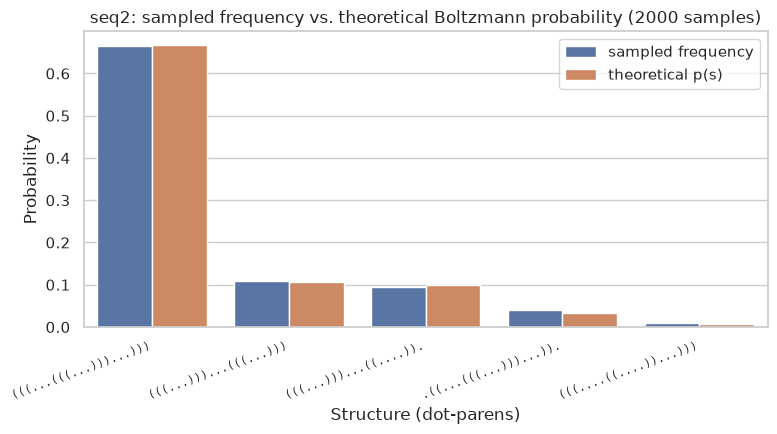

In [4]:
plot_df = comparison.melt(
    id_vars=["structure", "is_mfe"],
    value_vars=["sampled frequency", "theoretical p(s)"],
    var_name="estimate",
    value_name="probability",
)
plot_df["label"] = plot_df["structure"].apply(
    lambda s: s if len(s) <= 22 else s[:10] + "..." + s[-9:]
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=plot_df, x="label", y="probability", hue="estimate", ax=ax)
ax.set_xlabel("Structure (dot-parens)")
ax.set_ylabel("Probability")
ax.set_title("seq2: sampled frequency vs. theoretical Boltzmann probability (2000 samples)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontfamily="monospace", fontsize=8)
ax.legend(title=None)
fig.tight_layout()
plt.show()


**Interpretation.** The sampled frequencies track the theoretical
probabilities closely - small differences are sampling noise (with 2000
draws, a structure with $p(s) \approx 0.1$ has a standard error of roughly
$\sqrt{0.1 \times 0.9 / 2000} \approx 0.007$). The MFE structure dominates with
$p \approx 0.6$-$0.7$, consistent with the $\sim$1.1 kcal/mol gap to its
nearest competitor from lesson 2 ($\Delta G \approx 1.1$ kcal/mol corresponds
to $e^{-\Delta G / RT} \approx 0.16$, i.e. the second structure is roughly
6x less probable - matching the ratio of the two bars).


## Worked example 2: a melting curve for individual base pairs

Lesson 1's 13-nt hairpin (`CGCGCUUUGCGCG`) had an interior stem pair with
$P_{ij} \ge 0.98$ at 37 deg C, but its terminal pair $(0, 12)$ was only 0.62 -
"end fraying". Let's track both pairs across a temperature range and see how
that gap evolves.


In [5]:
hairpin = Strand("CGCGCUUUGCGCG", name="hairpin")
hairpin_complex = Complex([hairpin], name="hairpin_complex")

temperatures = list(range(10, 91, 10))
terminal_prob = []
interior_prob = []

for celsius in temperatures:
    model_t = Model(material="rna", celsius=celsius, sodium=1.0)
    result_t = complex_analysis(
        complexes=[hairpin_complex], model=model_t, compute=["pfunc", "pairs"]
    )[hairpin_complex]
    p = result_t.pairs.to_array()
    terminal_prob.append(p[0, 12])   # outermost stem pair
    interior_prob.append(p[2, 10])   # interior stem pair

melt_df = pd.DataFrame(
    {
        "Temperature (deg C)": temperatures,
        "Terminal pair (0,12)": terminal_prob,
        "Interior pair (2,10)": interior_prob,
    }
)
display(melt_df)


,Temperature (deg C),"Terminal pair (0,12)","Interior pair (2,10)"
0,10,0.739249,0.999877
1,20,0.698913,0.999571
2,30,0.654301,0.998609
3,40,0.604671,0.995777
4,50,0.548524,0.987764
5,60,0.482085,0.964739
6,70,0.394064,0.893698
7,80,0.261427,0.687835
8,90,0.109314,0.342183


## Visualization: melting curve

A line plot of pairing probability vs. temperature - one curve per base pair
- is the classic "melting curve" view, here applied to two pairs of the same
hairpin instead of two different molecules.


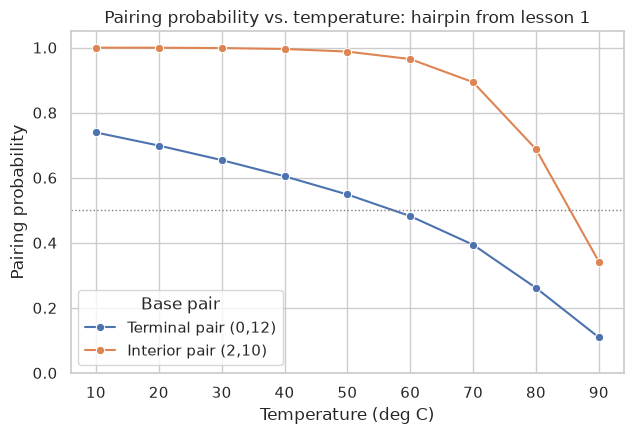

In [6]:
melt_long = melt_df.melt(
    id_vars="Temperature (deg C)", var_name="Base pair", value_name="Pairing probability"
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.lineplot(
    data=melt_long, x="Temperature (deg C)", y="Pairing probability", hue="Base pair", marker="o", ax=ax
)
ax.set_ylim(0, 1.05)
ax.set_title("Pairing probability vs. temperature: hairpin from lesson 1")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
fig.tight_layout()
plt.show()


**Interpretation.** Both curves decrease with temperature, but not in lockstep.
The **terminal** pair $(0,12)$ is already down to 0.74 at 10 deg C and falls
roughly linearly, crossing $p = 0.5$ between 50 and 60 deg C. The **interior**
pair $(2,10)$ stays pinned near 1.0 until about 50 deg C and then drops
sharply, not crossing $p = 0.5$ until past 90 deg C - it only "lets go" once
the rest of the stem (including the terminal pair) has substantially
destabilized, because losing an interior pair means breaking a stack on
*both* sides at once. This is the **cooperativity** of helix melting: the
terminal pair frays gradually and more or less independently, while interior
pairs stay almost fully formed over a wide range and then melt abruptly -
which is also why "end fraying" in lesson 1 was visible at 37 deg C for the
terminal pair only.


## Best practices and common pitfalls

- **Sampling is stochastic - check convergence, not single draws.** A handful
  of samples can look qualitatively different from the true distribution;
  for probabilities around 0.1, a few thousand samples are needed to get
  the standard error below 1%. If you need precise probabilities, use
  `compute=["pairs"]` (exact) rather than estimating them from samples.
- **`subopt` energies and `pfunc`'s `free_energy` must come from the same
  `Model`/temperature** when computing theoretical probabilities - mixing
  energies computed at different temperatures will give nonsensical $p(s)$
  values.
- **A melting curve needs a `Model` per temperature.** `Model(material="rna",
  celsius=T, sodium=1.0)` must be rebuilt for each $T$; reusing one `Model`
  object across a loop without updating it will silently reuse the first
  temperature for every iteration.
- **Don't expect every base pair to melt at the same temperature.** Even
  within one stem, terminal and interior pairs can have very different
  melting behavior, as the example above shows - "the melting temperature of
  the hairpin" is really shorthand for a range of pair-specific transitions.


## Summary

In this notebook you:

1. Sampled structures from the Boltzmann ensemble with `compute=["sample"]`
   and verified that sampled frequencies match theoretical probabilities
   $p(s) = \exp(-(G(s) - \Delta G^{\circ})/RT)$ derived from `subopt` energies.
2. Swept temperature for the lesson-1 hairpin and produced a melting curve for
   an interior vs. a terminal base pair, explaining the difference via
   cooperativity.

**Next:** [`04_defect_analysis.ipynb`](04_defect_analysis.ipynb) introduces
the **ensemble defect** - a single number summarizing how well a *target*
structure matches the whole ensemble, building directly on the pair
probabilities used throughout this notebook.


## Exercises

1. Increase `num_sample` to 10000 and re-run the comparison. Do the sampled
   frequencies for the less common structures (rank 3-5) get closer to their
   theoretical values?
2. Add `celsius=37` explicitly to the `temperatures` list (it falls between
   the existing 30 and 40 points) and re-plot. Where do the values for both
   pairs at 37 deg C fall relative to the lesson 1 results ($P_{(0,12)}
   \approx 0.62$, $P_{(2,10)} \approx 0.997$)?
